# XGBoost backcasting notebook: global model + NNH-specific models

Dieses Notebook trainiert

- ein globales XGBoost-Modell auf allen Daten,
- drei separate Modelle für `nnh_region = 1, 2, 3`,
- und erzeugt Vergleichsplots für Performance, Trainingsverlauf und Feature Importance.

Der Workflow ist bewusst an dein bisheriges R-Skript angelehnt:

1. Daten laden  
2. Features auswählen (`ibap_B*_med` + `nbr_sen_slope`)  
3. tile-basierten Train/Val/Test-Split erzeugen  
4. Evaluationsmodell mit Early Stopping trainieren  
5. Threshold auf dem Validation-Set optimieren  
6. Testmetriken berechnen  
7. finalen Produktions-Classifier auf allen Zeilen der jeweiligen Teilmenge trainieren  
8. Vergleichsplots erzeugen

In [ ]:
# Optional: install missing packages in the notebook environment
# Uncomment if needed.

# %pip install pandas numpy scikit-learn xgboost matplotlib seaborn pyarrow

In [13]:
import sys
import subprocess
import importlib
from pathlib import Path
import xgboost as xgb

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
)

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
}

missing = []

for import_name, pip_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f"{import_name} already installed")
    except ImportError:
        missing.append(pip_name)

if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are already installed")

numpy already installed
pandas already installed
matplotlib already installed
sklearn already installed
xgboost already installed
All required packages are already installed


In [3]:
# ----------------------------
# SETTINGS
# ----------------------------

IN_FILE = "/mnt/eo/EO4Backcasting/model_input/training_biomes.csv"
OUT_ROOT = "/mnt/eo/EO4Backcasting/_training_output"

Path(OUT_ROOT).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1) < 1e-8

XGB_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="logloss",
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    n_estimators=1000,
    random_state=RANDOM_STATE,
    n_jobs=max(1, (os.cpu_count() or 2) - 1),
)

EARLY_STOPPING_ROUNDS = 40
THRESHOLD_GRID = np.round(np.arange(0.10, 0.901, 0.01), 2)

In [4]:
# ----------------------------
# HELPERS
# ----------------------------

def safe_auc(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    ok = np.isfinite(y_true) & np.isfinite(y_prob)
    y_true = y_true[ok]
    y_prob = y_prob[ok]
    if len(np.unique(y_true)) < 2:
        return np.nan
    return float(roc_auc_score(y_true, y_prob))


def calc_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    ok = np.isfinite(y_true) & np.isfinite(y_prob)
    y_true = y_true[ok]
    y_prob = y_prob[ok]

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan,
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "auc": safe_auc(y_true, y_prob),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }


def find_best_f1_threshold(y_true, y_prob, thresholds=THRESHOLD_GRID):
    rows = [calc_metrics(y_true, y_prob, thr) for thr in thresholds]
    out = pd.DataFrame(rows)
    out = out.sort_values(["f1", "threshold"], ascending=[False, True]).reset_index(drop=True)
    return out.iloc[0], out


def feature_label(feature):
    if feature == "nbr_sen_slope":
        return "NBR slope"
    if feature.startswith("ibap_B") and feature.endswith("_med"):
        band_num = feature.replace("ibap_B", "").replace("_med", "")
        return f"Band {band_num}"
    return feature


def model_label(model_name):
    mapping = {
        "global": "Global",
        "nnh_region_1": "Boreal",
        "nnh_region_2": "Temperate",
        "nnh_region_3": "Mediterranean",
    }
    return mapping.get(model_name, model_name)


def ensure_binary_labels(y, model_name, split_name):
    u = sorted(pd.Series(y).dropna().unique().tolist())
    if not set(u).issubset({0, 1}):
        raise ValueError(f"{model_name} / {split_name}: labels are not binary 0/1: {u}")
    if len(u) < 2:
        print(f"Warning: {model_name} / {split_name} contains only one class. AUC will be NaN.")


def make_tile_split(df, tile_col="tile", train_frac=0.7, val_frac=0.15, random_state=42):
    tiles = pd.Series(df[tile_col].dropna().unique()).sample(frac=1, random_state=random_state).tolist()

    n_tiles = len(tiles)
    n_train = int(np.floor(n_tiles * train_frac))
    n_val = int(np.floor(n_tiles * val_frac))
    n_test = n_tiles - n_train - n_val

    if min(n_train, n_val, n_test) < 1:
        raise ValueError("Too few tiles for requested train/val/test split.")

    train_tiles = set(tiles[:n_train])
    val_tiles = set(tiles[n_train:n_train + n_val])
    test_tiles = set(tiles[n_train + n_val:])

    split = np.where(
        df[tile_col].isin(train_tiles), "train",
        np.where(df[tile_col].isin(val_tiles), "val", "test")
    )

    out = df.copy()
    out["split"] = split
    return out, sorted(train_tiles), sorted(val_tiles), sorted(test_tiles)

In [8]:
# ----------------------------
# LOAD DATA
# ----------------------------

df = pd.read_csv(IN_FILE)

required_cols = ["point_id", "tile", "label_undisturbed_20y", "nbr_sen_slope", "NNH"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

ibap_cols = [c for c in df.columns if c.startswith("ibap_B") and c.endswith("_med")]
ibap_cols = sorted(
    ibap_cols,
    key=lambda x: int(x.replace("ibap_B", "").replace("_med", ""))
)

if len(ibap_cols) == 0:
    raise ValueError("No IBAP feature columns found.")

FEATURE_COLS = ibap_cols + ["nbr_sen_slope"]

for c in FEATURE_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["label_undisturbed_20y"] = pd.to_numeric(df["label_undisturbed_20y"], errors="coerce").astype("Int64")
df["NNH"] = pd.to_numeric(df["NNH"], errors="coerce").astype("Int64")

n_before = len(df)
df = df[df["label_undisturbed_20y"].isin([0, 1])].copy()
df = df[df["NNH"].isin([1, 2, 3])].copy()
df = df.dropna(subset=FEATURE_COLS + ["point_id", "tile", "label_undisturbed_20y", "NNH"]).copy()

df["label_undisturbed_20y"] = df["label_undisturbed_20y"].astype(int)
df["NNH"] = df["NNH"].astype(int)

# Rename / label NNH classes
nnh_map = {
    1: "Boreal",
    2: "Temperate",
    3: "Mediterranean",
}
df["NNH_name"] = df["NNH"].map(nnh_map)

# Optional: ordered categorical for cleaner plots/tables
df["NNH_name"] = pd.Categorical(
    df["NNH_name"],
    categories=["Boreal", "Temperate", "Mediterranean"],
    ordered=True
)

print(f"Removed rows: {n_before - len(df):,}")
print(f"Rows kept: {len(df):,}")
print(f"Tiles kept: {df['tile'].nunique():,}")

print("Class balance:")
display(
    df["label_undisturbed_20y"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n_rows")
    .to_frame()
)

print("NNH balance (numeric):")
display(
    df["NNH"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n_rows")
    .to_frame()
)

print("NNH balance (named):")
display(
    df["NNH_name"]
    .value_counts(dropna=False)
    .sort_index()
    .rename("n_rows")
    .to_frame()
)

Removed rows: 0
Rows kept: 390,987
Tiles kept: 395
Class balance:


,n_rows
label_undisturbed_20y,
0,195091
1,195896


NNH balance (numeric):


,n_rows
NNH,
1,66374
2,233714
3,90899


NNH balance (named):


,n_rows
NNH_name,
Boreal,66374
Temperate,233714
Mediterranean,90899


## Modellfunktion

Die nächste Zelle führt den kompletten Workflow für eine Teilmenge aus:

- tile-basierter Split  
- Evaluationsmodell mit Early Stopping  
- Metriken für `0.5` und optimalen Validation-Threshold  
- Export von CSVs, PNGs und finalem Modell  
- Rückgabe aller Ergebnisse für den späteren Vergleich

In [9]:
def run_xgb_workflow(
    df_sub,
    model_name,
    feature_cols,
    out_root,
    params,
    early_stopping_rounds=40,
    train_frac=0.70,
    val_frac=0.15,
    random_state=42,
):
    out_dir = Path(out_root) / model_name
    plot_dir = out_dir / "plots"
    out_dir.mkdir(parents=True, exist_ok=True)
    plot_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 70)
    print(f"Running model: {model_name}")
    print(f"Rows:  {len(df_sub):,}")
    print(f"Tiles: {df_sub['tile'].nunique():,}")
    print(df_sub["label_undisturbed_20y"].value_counts().sort_index())

    df_split, train_tiles, val_tiles, test_tiles = make_tile_split(
        df_sub,
        tile_col="tile",
        train_frac=train_frac,
        val_frac=val_frac,
        random_state=random_state,
    )

    train_df = df_split[df_split["split"] == "train"].copy()
    val_df = df_split[df_split["split"] == "val"].copy()
    test_df = df_split[df_split["split"] == "test"].copy()

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError(f"{model_name}: one split is empty.")

    ensure_binary_labels(train_df["label_undisturbed_20y"], model_name, "train")
    ensure_binary_labels(val_df["label_undisturbed_20y"], model_name, "val")
    ensure_binary_labels(test_df["label_undisturbed_20y"], model_name, "test")

    X_train = train_df[feature_cols].to_numpy(dtype=float)
    y_train = train_df["label_undisturbed_20y"].to_numpy(dtype=int)

    X_val = val_df[feature_cols].to_numpy(dtype=float)
    y_val = val_df["label_undisturbed_20y"].to_numpy(dtype=int)

    X_test = test_df[feature_cols].to_numpy(dtype=float)
    y_test = test_df["label_undisturbed_20y"].to_numpy(dtype=int)

    # ----------------------------
    # evaluation model with early stopping
    # ----------------------------
    model_eval = xgb.XGBClassifier(**params)
    model_eval.fit(
        X_train,
        y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False,
    )

    evals_result = model_eval.evals_result()
    train_logloss = evals_result["validation_0"]["logloss"]
    val_logloss = evals_result["validation_1"]["logloss"]

    best_iter = getattr(model_eval, "best_iteration", None)
    if best_iter is None:
        best_iter = int(np.argmin(val_logloss))

    pred_train = model_eval.predict_proba(X_train)[:, 1]
    pred_val = model_eval.predict_proba(X_val)[:, 1]
    pred_test = model_eval.predict_proba(X_test)[:, 1]

    # ----------------------------
    # best threshold from validation set using F1 optimization
    # ----------------------------
    best_thr_row, thr_grid = find_best_f1_threshold(y_val, pred_val)
    best_thr = float(best_thr_row["threshold"])

    metrics_rows = []
    for split_name, y_true, y_prob in [
        ("train", y_train, pred_train),
        ("val", y_val, pred_val),
        ("test", y_test, pred_test),
    ]:
        m_fixed = calc_metrics(y_true, y_prob, threshold=0.5)
        m_fixed["split"] = split_name
        m_fixed["threshold_type"] = "fixed_0.5"
        m_fixed["model"] = model_name

        m_opt = calc_metrics(y_true, y_prob, threshold=best_thr)
        m_opt["split"] = split_name
        m_opt["threshold_type"] = "best_val_f1"
        m_opt["model"] = model_name

        metrics_rows.extend([m_fixed, m_opt])

    metrics_all = pd.DataFrame(metrics_rows)

    auc_summary = pd.DataFrame({
        "model": [model_name, model_name, model_name],
        "split": ["train", "val", "test"],
        "auc": [
            safe_auc(y_train, pred_train),
            safe_auc(y_val, pred_val),
            safe_auc(y_test, pred_test),
        ]
    })

    importance = pd.DataFrame({
        "Feature": feature_cols,
        "Gain": model_eval.feature_importances_,
    }).sort_values("Gain", ascending=False).reset_index(drop=True)
    importance["model"] = model_name
    importance["Feature_clean"] = importance["Feature"].map(feature_label)
    importance["rank_gain"] = np.arange(1, len(importance) + 1)

    pred_out = pd.DataFrame({
        "model": model_name,
        "point_id": test_df["point_id"].values,
        "tile": test_df["tile"].values,
        "y_true": y_test,
        "p_undisturbed": pred_test,
        "pred_class_05": (pred_test >= 0.5).astype(int),
        "pred_class_opt": (pred_test >= best_thr).astype(int),
    })

    eval_log = pd.DataFrame({
        "iter": np.arange(1, len(train_logloss) + 1),
        "train_logloss": train_logloss,
        "val_logloss": val_logloss,
        "model": model_name,
    })

    # save tabular outputs
    pd.DataFrame({"feature": feature_cols}).to_csv(out_dir / "feature_list.csv", index=False)
    pd.DataFrame({"tile": train_tiles, "split": "train"}).to_csv(out_dir / "tiles_train.csv", index=False)
    pd.DataFrame({"tile": val_tiles, "split": "val"}).to_csv(out_dir / "tiles_val.csv", index=False)
    pd.DataFrame({"tile": test_tiles, "split": "test"}).to_csv(out_dir / "tiles_test.csv", index=False)

    pd.DataFrame([best_thr_row]).to_csv(out_dir / "best_threshold_from_val.csv", index=False)
    metrics_all.to_csv(out_dir / "metrics_all_splits.csv", index=False)
    auc_summary.to_csv(out_dir / "auc_summary.csv", index=False)
    importance.to_csv(out_dir / "feature_importance.csv", index=False)
    pred_out.to_csv(out_dir / "test_predictions.csv", index=False)
    eval_log.to_csv(out_dir / "evaluation_log.csv", index=False)
    thr_grid.to_csv(out_dir / "validation_threshold_grid.csv", index=False)

    model_eval.save_model(out_dir / "xgb_model_eval.json")

    # ----------------------------
    # final model trained on all rows of subset
    # use best iteration from eval model
    # ----------------------------
    X_all = df_sub[feature_cols].to_numpy(dtype=float)
    y_all = df_sub["label_undisturbed_20y"].to_numpy(dtype=int)

    final_params = dict(params)
    final_params["n_estimators"] = best_iter + 1

    model_final = xgb.XGBClassifier(**final_params)
    model_final.fit(X_all, y_all, verbose=False)
    model_final.save_model(out_dir / "xgb_model_final.json")

    # ----------------------------
    # PLOTS
    # ----------------------------

    # 1) Training history: logloss
    fig, ax = plt.subplots()
    ax.plot(eval_log["iter"], eval_log["train_logloss"], label="train")
    ax.plot(eval_log["iter"], eval_log["val_logloss"], label="validation")
    ax.axvline(best_iter + 1, linestyle="--", label="best iteration")
    ax.set_title(f"Training history: logloss ({model_label(model_name)})")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Logloss")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_dir / "training_history_logloss.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 2) AUC by split
    fig, ax = plt.subplots()
    ax.bar(auc_summary["split"], auc_summary["auc"])
    ax.set_title(f"AUC by split ({model_label(model_name)})")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("AUC")
    fig.tight_layout()
    fig.savefig(plot_dir / "auc_by_split.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 3) Feature importance
    feature_order = [f"Band {i}" for i in range(1, 7)] + ["NBR slope"]

    imp_plot = importance.copy()
    imp_plot = imp_plot[imp_plot["Feature_clean"].isin(feature_order)].copy()
    imp_plot["Feature_clean"] = pd.Categorical(
        imp_plot["Feature_clean"],
        categories=feature_order[::-1],
        ordered=True,
    )
    imp_plot = imp_plot.sort_values("Feature_clean")

    fig, ax = plt.subplots()
    ax.barh(imp_plot["Feature_clean"], imp_plot["Gain"])
    ax.set_title(f"Feature importance ({model_label(model_name)})")
    ax.set_xlabel("Gain")
    ax.set_ylabel("Feature")
    fig.tight_layout()
    fig.savefig(plot_dir / "feature_importance_ordered.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 4) Test prediction histogram
    fig, ax = plt.subplots()
    ax.hist(pred_test[y_test == 0], bins=40, alpha=0.5, label="disturbed")
    ax.hist(pred_test[y_test == 1], bins=40, alpha=0.5, label="undisturbed")
    ax.set_title(f"Predicted probabilities on test tiles ({model_label(model_name)})")
    ax.set_xlabel("Predicted probability of undisturbed")
    ax.set_ylabel("Count")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_dir / "test_prediction_histogram.png", dpi=300, bbox_inches="tight")
    plt.show()

    # 5) Validation threshold metrics
    fig, ax = plt.subplots()
    ax.plot(thr_grid["threshold"], thr_grid["precision"], label="precision")
    ax.plot(thr_grid["threshold"], thr_grid["recall"], label="recall")
    ax.plot(thr_grid["threshold"], thr_grid["f1"], label="f1")
    ax.axvline(best_thr, linestyle="--", label=f"best F1 threshold = {best_thr:.2f}")
    ax.set_title(f"Validation metrics across thresholds ({model_label(model_name)})")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Metric value")
    ax.legend()
    fig.tight_layout()
    fig.savefig(plot_dir / "validation_threshold_metrics.png", dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Best iteration: {best_iter + 1}")
    print(f"Best validation threshold (F1): {best_thr:.2f}")

    return {
        "model_name": model_name,
        "metrics_all": metrics_all,
        "auc_summary": auc_summary,
        "importance": importance,
        "evaluation_log": eval_log,
        "predictions": pred_out,
        "best_threshold": best_thr_row.to_dict(),
        "best_iteration": best_iter + 1,
        "model_eval": model_eval,
        "model_final": model_final,
    }

## Globales Modell und drei NNH-spezifische Modelle ausführen

Running model: global
Rows:  390,987
Tiles: 395
label_undisturbed_20y
0    195091
1    195896
Name: count, dtype: int64


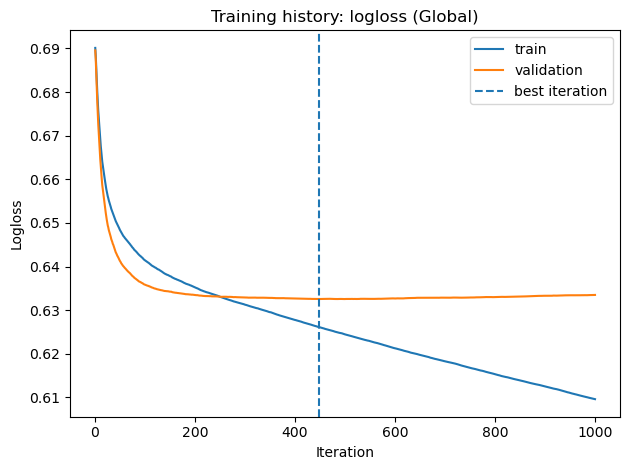

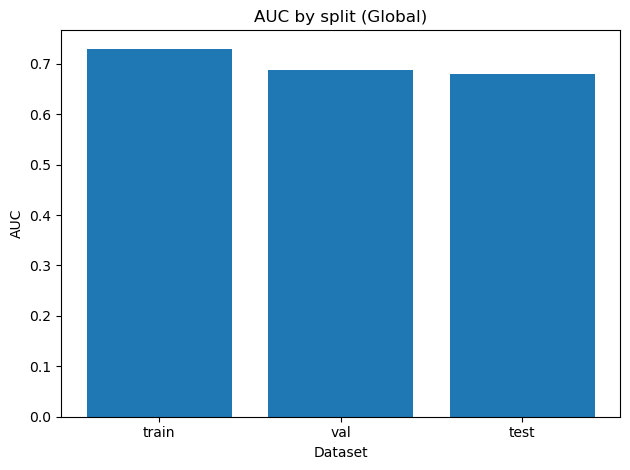

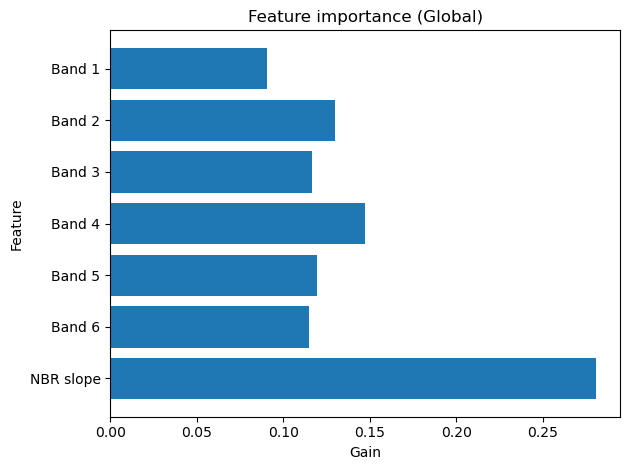

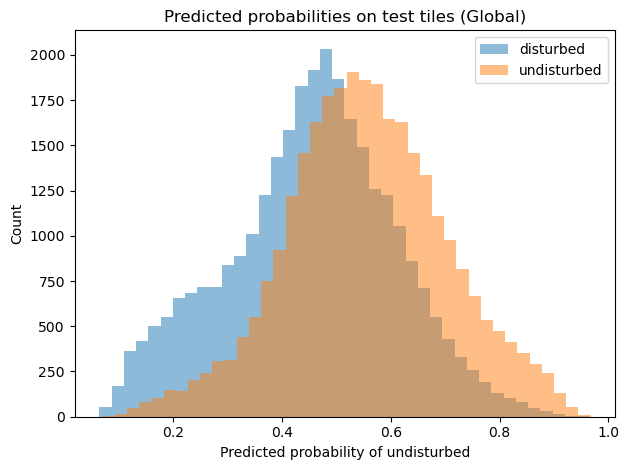

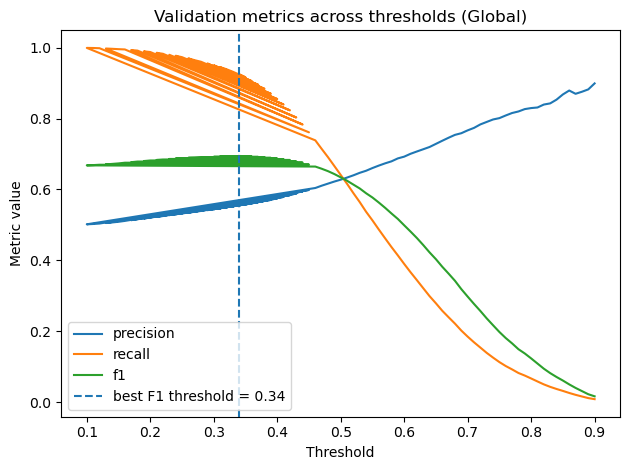

Best iteration: 449
Best validation threshold (F1): 0.34
Running model: nnh_region_1
Rows:  66,374
Tiles: 72
label_undisturbed_20y
0    33015
1    33359
Name: count, dtype: int64


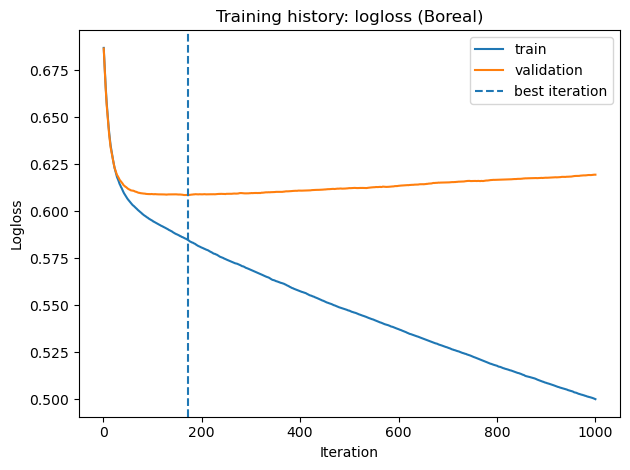

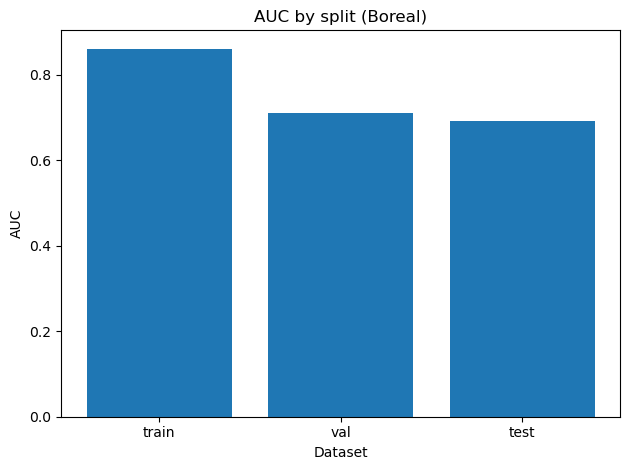

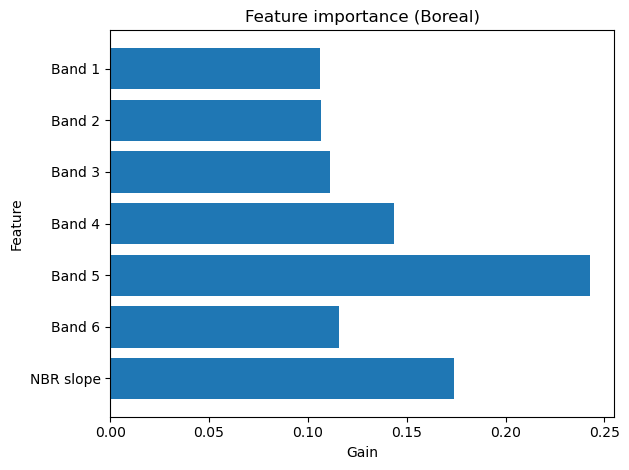

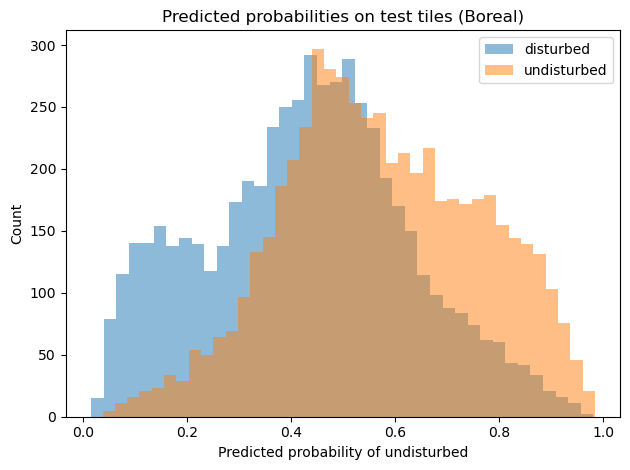

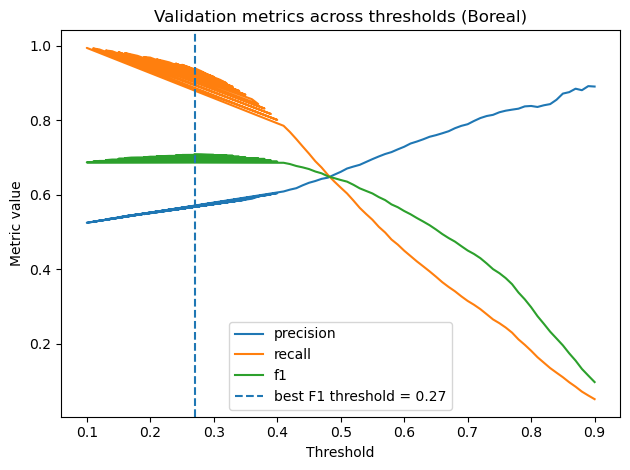

Best iteration: 172
Best validation threshold (F1): 0.27
Running model: nnh_region_2
Rows:  233,714
Tiles: 258
label_undisturbed_20y
0    116406
1    117308
Name: count, dtype: int64


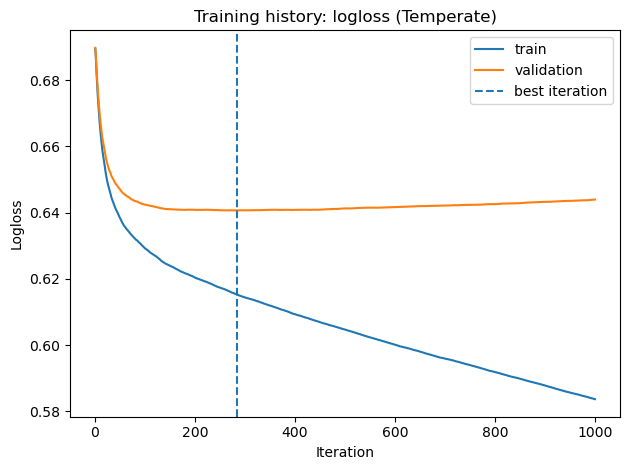

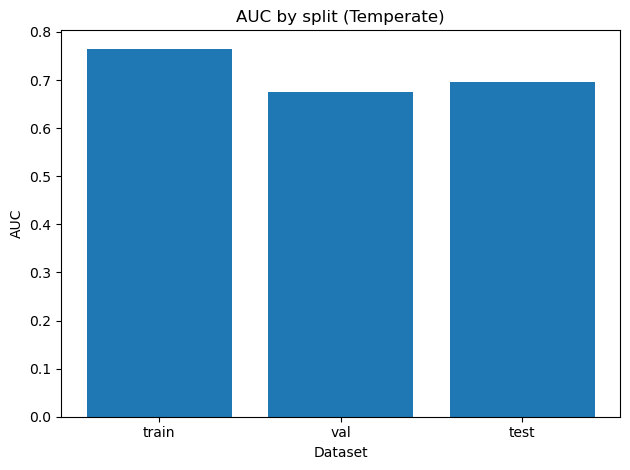

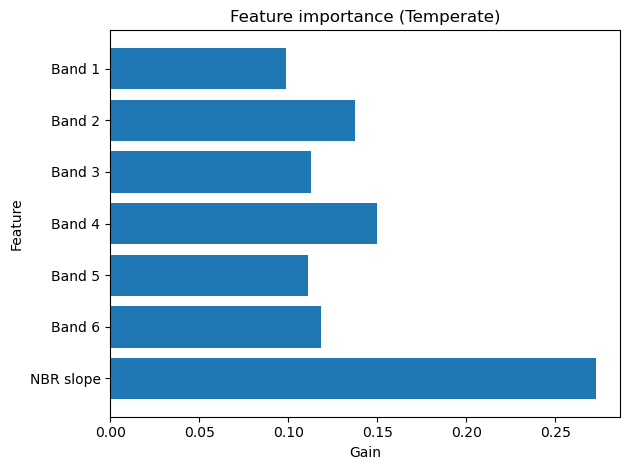

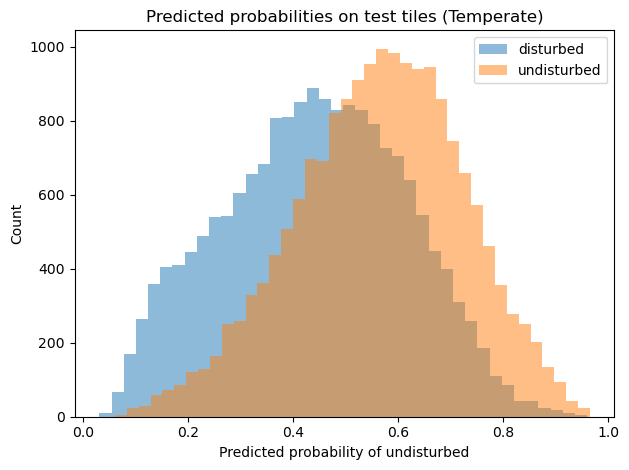

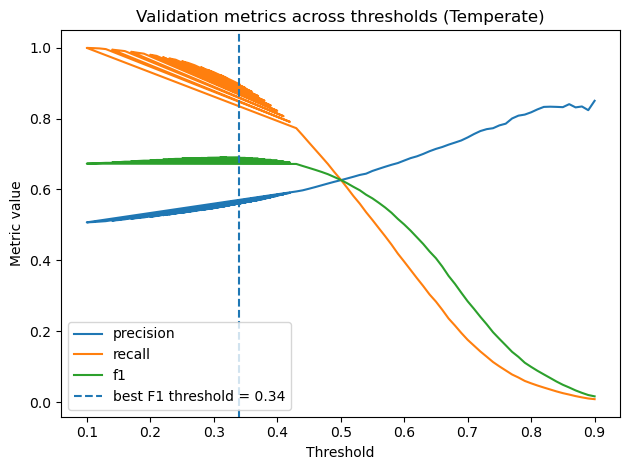

Best iteration: 284
Best validation threshold (F1): 0.34
Running model: nnh_region_3
Rows:  90,899
Tiles: 111
label_undisturbed_20y
0    45670
1    45229
Name: count, dtype: int64


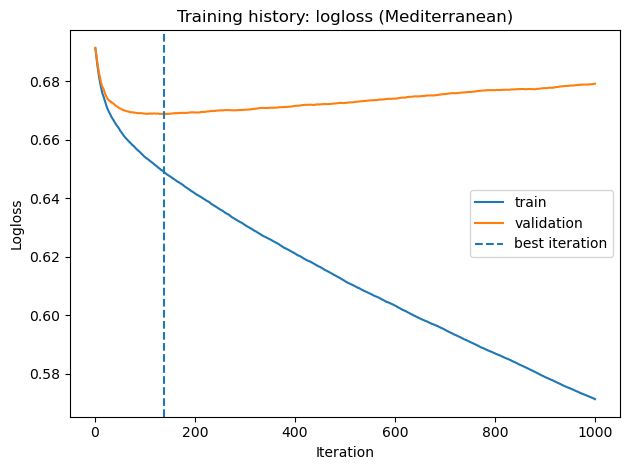

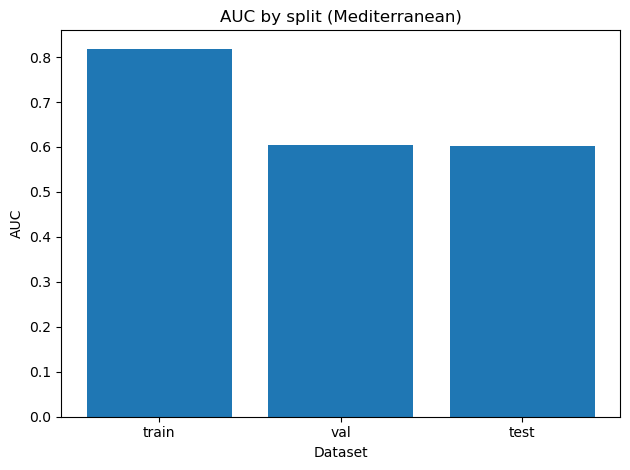

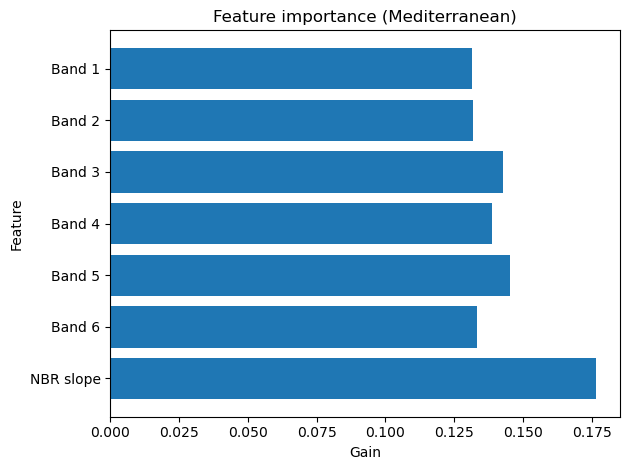

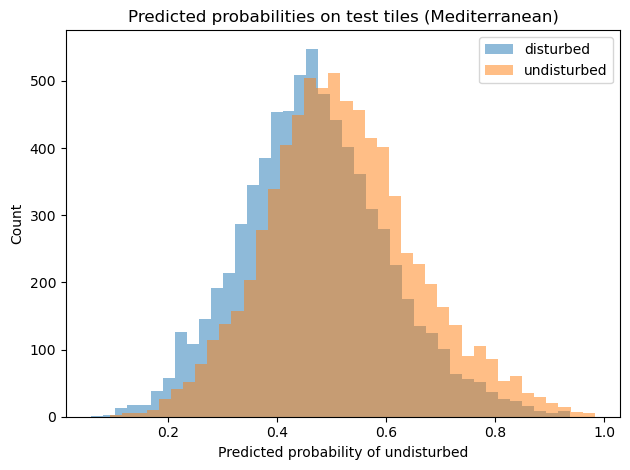

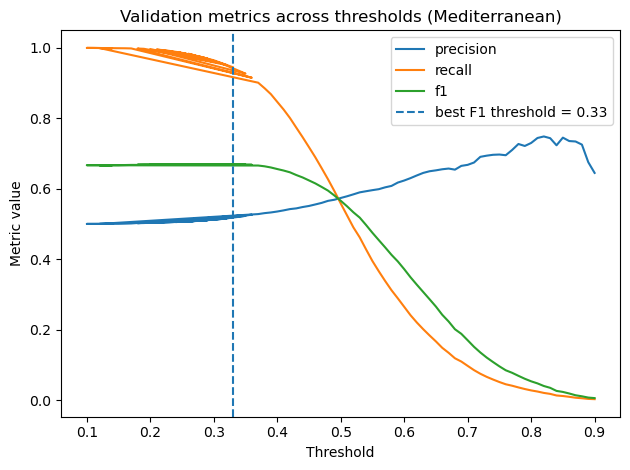

Best iteration: 139
Best validation threshold (F1): 0.33


In [14]:
model_specs = {
    "global": df.copy(),
    "nnh_region_1": df[df["NNH"] == 1].copy(),
    "nnh_region_2": df[df["NNH"] == 2].copy(),
    "nnh_region_3": df[df["NNH"] == 3].copy(),
}

results = {}

for model_name, df_sub in model_specs.items():
    if len(df_sub) == 0:
        print(f"Skipping {model_name}: empty subset")
        continue

    results[model_name] = run_xgb_workflow(
        df_sub=df_sub,
        model_name=model_name,
        feature_cols=FEATURE_COLS,
        out_root=OUT_ROOT,
        params=XGB_PARAMS,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        train_frac=TRAIN_FRAC,
        val_frac=VAL_FRAC,
        random_state=RANDOM_STATE,
    )

**Global**
  
Fig.1 : Logloss (global): Trainings-Logloss sinkt kontinuierlich, Valdierungs-Logloss flacht früh ab und steigt ganz leicht -> beginnendes overfitting.
Nach Iteration ~450 wird nur noch Trainngsfehler besser, nicht aber Generalisierung

Fig.2: AUC by split: Val und Test nah beinander, gut. Klassen werden nicht besonders gut getrennt.

Fig. 3: Feature importance: NBR slope wichtigster Prädiktor.

Fig.4: Predicted probablities on test tile: Verteilungen überlappen sehr stark. Passt zu nur mittel gutem Test AUC.

Fig.5: Validation metrics across thresholds: Beste F1 score bei ~0.34. Niedrig und zeigt, dass Modell für die undisturbed Klasse eher konservativ trennt. Bei höheren Schwellwerten steigt zwar Precision, aber recall bricht ein.

**Boreal**
Fig.6: Logloss boreal: Overfitting setzte früher ein. Early stopping macht hier Sinn

Fig- 8: Feature importance borel: Interessant: Band 5 am wichtigsten (SWIR), gefolgt von NBR slope

Fig. 9: Verteilung boreal: Histogramme etwas besser getrennt als im globalen Modell

**Temperate**
    
Fig. 10: Logloss temperate: Overfitting setzt erst später ein

Fig. 12: Feature importantce: NBR slope dominiert wieder

Fig. 13: Predicted probs: Klassen verschoben, aber immer noch überlappend

**Mediterran**

Fig. 14: Logloss: Deutliches overfitting, lernt Trainingsset gut aber generalisiert schlechter

Fig. 15: AUC: am schlechtesten

Fig. 16: Feature importance: Importance viel gleichmäßiger verteilt

Fig. 17: Histogramme überlappen sehr stark. Deshalb schwache Trennung

**Vergleichsplots**

- Regionale Modelle helfen nur teilweise, mediterran bleibt weiterhin schwierig

- Feature importance: NBR slope ist regionsabhängig und dort am wenigsten stabil, wo Modellgüte am schlechtesten

- ROC curves: Keines der Modelle trennt besonders gut


## Ergebnisse zusammenführen

In [15]:
metrics_compare = pd.concat([r["metrics_all"] for r in results.values()], ignore_index=True)
auc_compare = pd.concat([r["auc_summary"] for r in results.values()], ignore_index=True)
importance_compare = pd.concat([r["importance"] for r in results.values()], ignore_index=True)
eval_log_compare = pd.concat([r["evaluation_log"] for r in results.values()], ignore_index=True)

metrics_compare["model_clean"] = metrics_compare["model"].map(model_label)
auc_compare["model_clean"] = auc_compare["model"].map(model_label)
importance_compare["model_clean"] = importance_compare["model"].map(model_label)
eval_log_compare["model_clean"] = eval_log_compare["model"].map(model_label)

metrics_compare.to_csv(Path(OUT_ROOT) / "comparison_metrics_all_models.csv", index=False)
auc_compare.to_csv(Path(OUT_ROOT) / "comparison_auc_all_models.csv", index=False)
importance_compare.to_csv(Path(OUT_ROOT) / "comparison_feature_importance_all_models.csv", index=False)
eval_log_compare.to_csv(Path(OUT_ROOT) / "comparison_evaluation_logs_all_models.csv", index=False)

display(metrics_compare.head())
display(auc_compare)

,threshold,accuracy,precision,recall,specificity,f1,auc,tp,tn,fp,fn,split,threshold_type,model,model_clean
0,0.50,0.663894,0.662557,0.671697,0.656047,0.667096,0.729983,91684,89065,46695,44812,train,fixed_0.5,global,Global
1,0.34,0.594227,0.556491,0.939009,0.247577,0.698830,0.729983,128171,33611,102149,8325,train,best_val_f1,global,Global
2,0.50,0.630103,0.627601,0.640983,0.619209,0.634222,0.687727,18909,18245,11220,10591,val,fixed_0.5,global,Global
3,0.34,0.592708,0.555827,0.925424,0.259596,0.694515,0.687727,27300,7649,21816,2200,val,best_val_f1,global,Global
4,0.50,0.627999,0.624226,0.644247,0.611732,0.634079,0.680220,19263,18270,11596,10637,test,fixed_0.5,global,Global


,model,split,auc,model_clean
0,global,train,0.729983,Global
1,global,val,0.687727,Global
2,global,test,0.680220,Global
3,nnh_region_1,train,0.861479,Boreal
4,nnh_region_1,val,0.710324,Boreal
5,nnh_region_1,test,0.693138,Boreal
6,nnh_region_2,train,0.765060,Temperate
7,nnh_region_2,val,0.675113,Temperate
8,nnh_region_2,test,0.695222,Temperate
9,nnh_region_3,train,0.818540,Mediterranean


## Vergleichsplots

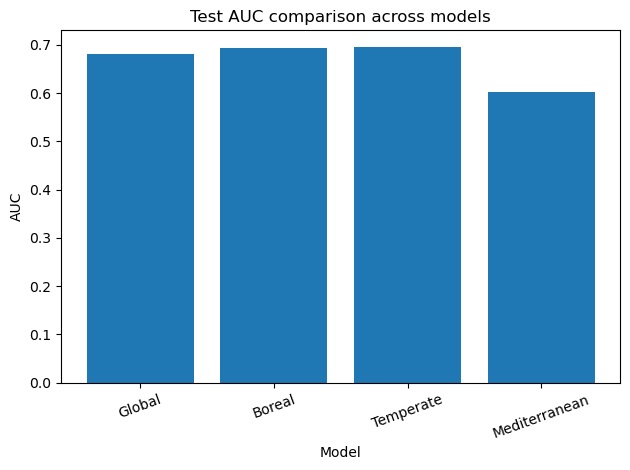

In [16]:
# 1) Test AUC comparison
auc_test = auc_compare[auc_compare["split"] == "test"].copy()
model_order = ["Global", "Boreal", "Temperate", "Mediterranean"]
auc_test["model_clean"] = pd.Categorical(auc_test["model_clean"], categories=model_order, ordered=True)
auc_test = auc_test.sort_values("model_clean")

fig, ax = plt.subplots()
ax.bar(auc_test["model_clean"], auc_test["auc"])
ax.set_title("Test AUC comparison across models")
ax.set_xlabel("Model")
ax.set_ylabel("AUC")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_test_auc.png", dpi=300, bbox_inches="tight")
plt.show()

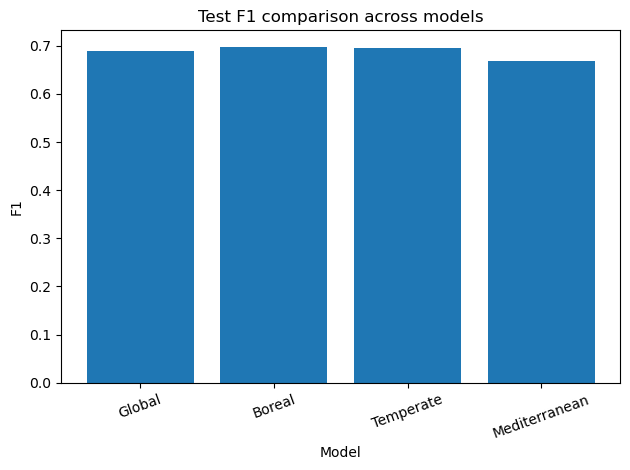

In [17]:
# 2) Test F1 comparison using best validation threshold
f1_test = metrics_compare[
    (metrics_compare["split"] == "test") &
    (metrics_compare["threshold_type"] == "best_val_f1")
].copy()

f1_test["model_clean"] = pd.Categorical(f1_test["model_clean"], categories=model_order, ordered=True)
f1_test = f1_test.sort_values("model_clean")

fig, ax = plt.subplots()
ax.bar(f1_test["model_clean"], f1_test["f1"])
ax.set_title("Test F1 comparison across models")
ax.set_xlabel("Model")
ax.set_ylabel("F1")
plt.xticks(rotation=20)
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_test_f1.png", dpi=300, bbox_inches="tight")
plt.show()

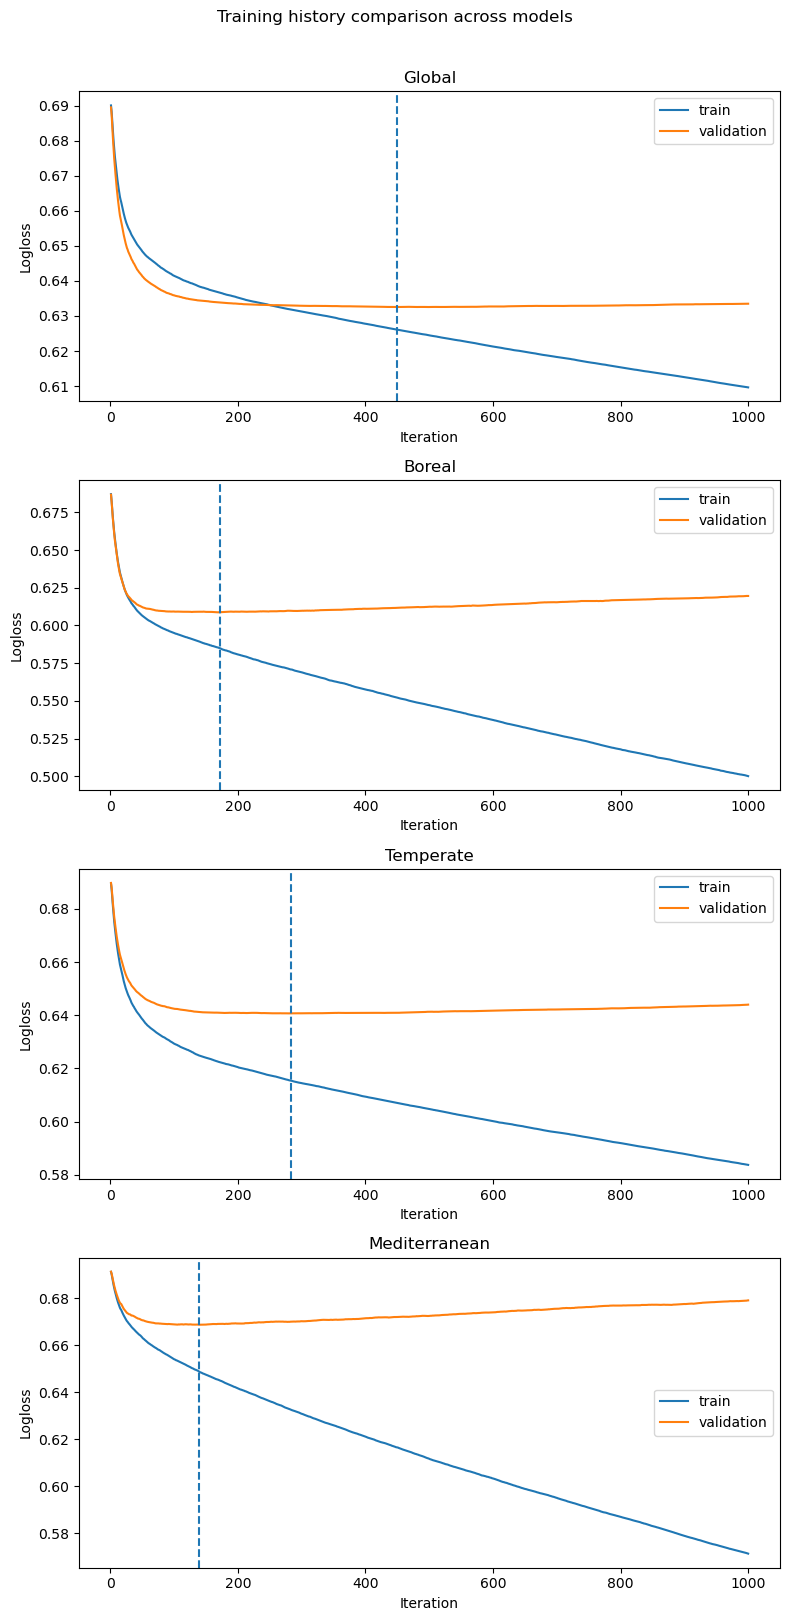

In [18]:
# 3) Training history comparison
n_models = len(results)
fig, axes = plt.subplots(n_models, 1, figsize=(8, 4 * n_models), sharex=False)

if n_models == 1:
    axes = [axes]

for ax, (model_name, res) in zip(axes, results.items()):
    elog = res["evaluation_log"].copy()
    ax.plot(elog["iter"], elog["train_logloss"], label="train")
    ax.plot(elog["iter"], elog["val_logloss"], label="validation")
    ax.axvline(res["best_iteration"], linestyle="--")
    ax.set_title(model_label(model_name))
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Logloss")
    ax.legend()

fig.suptitle("Training history comparison across models", y=1.01)
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_training_history_logloss.png", dpi=300, bbox_inches="tight")
plt.show()

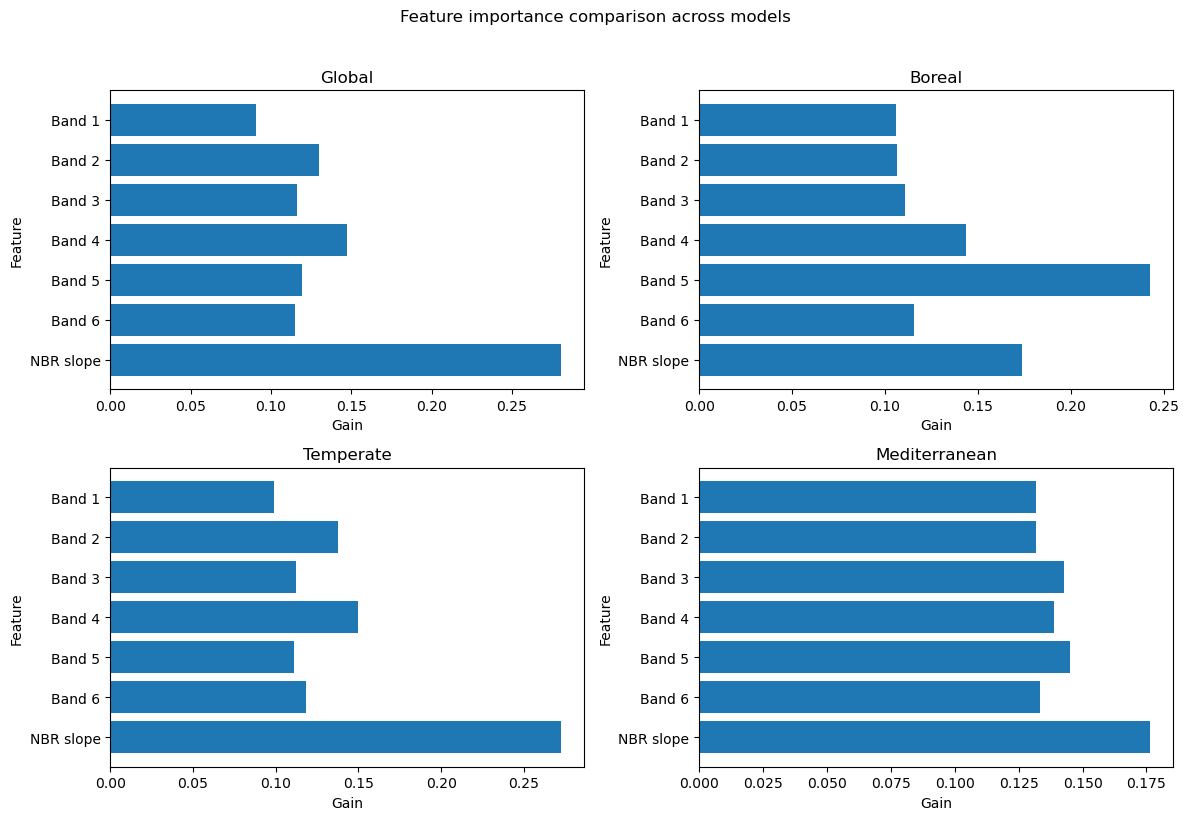

In [19]:
# 4) Feature importance comparison with requested labels and ordering
feature_order = [f"Band {i}" for i in range(1, 7)] + ["NBR slope"]

imp_plot = importance_compare.copy()
imp_plot["Feature_clean"] = imp_plot["Feature"].map(feature_label)
imp_plot = imp_plot[imp_plot["Feature_clean"].isin(feature_order)].copy()
imp_plot["Feature_clean"] = pd.Categorical(
    imp_plot["Feature_clean"],
    categories=feature_order[::-1],
    ordered=True
)
imp_plot["model_clean"] = pd.Categorical(
    imp_plot["model_clean"],
    categories=model_order,
    ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=False)
axes = axes.ravel()

for ax, model_name in zip(axes, model_order):
    sub = imp_plot[imp_plot["model_clean"] == model_name].sort_values("Feature_clean")
    ax.barh(sub["Feature_clean"], sub["Gain"])
    ax.set_title(model_name)
    ax.set_xlabel("Gain")
    ax.set_ylabel("Feature")

fig.suptitle("Feature importance comparison across models", y=1.02)
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_feature_importance_ordered.png", dpi=300, bbox_inches="tight")
plt.show()

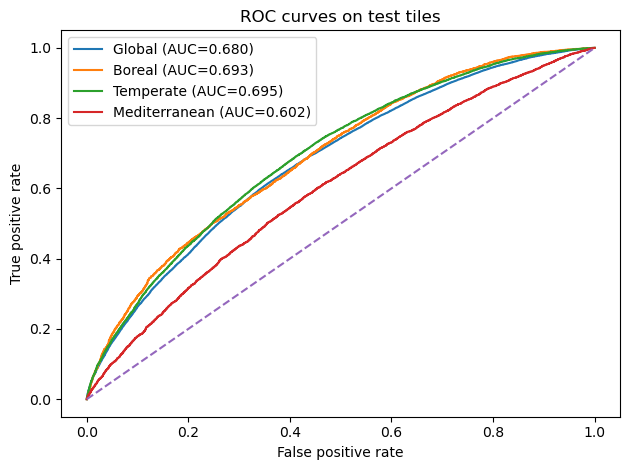

In [20]:
# 5) ROC curves on test split
fig, ax = plt.subplots()

for model_name, res in results.items():
    pred_df = res["predictions"]
    y_true = pred_df["y_true"].to_numpy()
    y_prob = pred_df["p_undisturbed"].to_numpy()

    if len(np.unique(y_true)) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = safe_auc(y_true, y_prob)
    ax.plot(fpr, tpr, label=f"{model_label(model_name)} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC curves on test tiles")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend()
fig.tight_layout()
fig.savefig(Path(OUT_ROOT) / "comparison_test_roc_curves.png", dpi=300, bbox_inches="tight")
plt.show()

## Short interpretation


- Test AUC / Test F1: shows whether regional models truly generalize better than the global model.   
- Training history: shows whether individual NNH models overfit more quickly or converge more stably.  
- Feature importance: shows whether the relative importance of the spectral bands and the NBR slope shifts between Boreal, Temperate, and Mediterranean.  
- ROC curves: shows differences in discrimination across all thresholds.

In [ ]:
print("Notebook finished.")
print("Outputs written to:", OUT_ROOT)